In [1]:
import numpy as np 
import h5py
import matplotlib.pyplot as plt
import scipy.io
import os
import re
from utils import *
from sklearn.linear_model import LinearRegression

In [5]:
###############################################
runNumbers = [15,16]  # enter the run numbers to be loaded
#folder = '/sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/' # insert here the directory path where .h5 files are stored
folder = '/sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/'
###############################################
# (1) keys_to_combine: some keys loaded for each shot & stored per shot 
# (2) keys_to_sum: some keys loaded per each run and added 
# (3) keys_to_check : check if some keys exits and have same values in all runs and load these keys 
keys_to_combine = ['CXI-DG2-BMMON-WF/ROI_rebin_data',
                   #'CXI-DG2-BMMON-WF/ROI_area',
                    'jungfrau4M/azav_mask0_azav', # Unfiltered
                   'jungfrau4M/azav_mask1_azav', # Filtered
                   'ipm_dg2/sum',
                    #'ipm_dg3/sum',
                   #'ipm_hfx_dg2/sum',
                   'gas_detector/f_11_ENRC',
                   'ebeam/photon_energy',
                   'evr/code_183',
                   'evr/code_137',
                   'evr/code_141',
                   'lightStatus/xray',
                  #'CXI-DG2-BMMON-WF/cxi_dg2_bmmon_wf_rebin_data',
                  'jungfrau4M/Full_thres_sum',
                  'feeBld/hproj',
                  'lightStatus/laser',
                  #'dg2_traces'
                  ]

keys_to_sum = ['Sums/jungfrau4M_calib']
#               'Sums/jungfrau4M_calib_thresADU1']

keys_to_check = ['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_q',
                 'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_idxq',
                 'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_idxq',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbin',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbins',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask',
                'UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask',
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_q', # This are only needed once
                'UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_phi', # This are only needed once
                'UserDataCfg/jungfrau4M/x',
                'UserDataCfg/jungfrau4M/y',
                'UserDataCfg/jungfrau4M/z',
                'UserDataCfg/jungfrau4M/cmask']
# Load the data in
data = combineRuns(runNumbers, folder, keys_to_combine, keys_to_sum, keys_to_check, verbose=False)  # this is the function to load the data with defined keys

# Filtered Data
azavFiltered = np.squeeze(data['jungfrau4M/azav_mask0_azav']) # I(q) : 1D azimuthal average of signals in each q bin
qbinFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbin'] # q bin-size
qFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_q'] # q bins 
qbinsFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_qbins'] # q bins
userMaskFiltered = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_userMask'].astype(bool) # User mask for this region
qbinSizeFiltered = np.bincount(data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_idxq'])
# Unfiltered Data
azav = np.squeeze(data['jungfrau4M/azav_mask1_azav']) # I(q) : 1D azimuthal average of signals in each q bin
qbin = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbin'] # q bin-size
q = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_q'] # q bins 
qbins = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_qbins'] # q bins
userMask = data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_userMask'].astype(bool) # User mask for this region
qbinSize = np.bincount(data['UserDataCfg/jungfrau4M/azav_mask1__azav_mask1_idxq'])
# Other Data
matrix_q = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_q'].reshape(8,512,1024) # Q values J4M shaped
matrix_phi = data['UserDataCfg/jungfrau4M/azav_mask0__azav_mask0_matrix_phi'].reshape(8,512,1024) # phi valyes J4M shaped
xrayOn = data['evr/code_137'].astype(bool)  # xray on events
xrayOn2 = data['lightStatus/xray'].astype(bool)  # xray on events
laserOn = data['lightStatus/laser'].astype(bool)  # xray on events
jungfrau_sum = data['Sums/jungfrau4M_calib']  # Total Jungfrau detector counts summed in a run
#jungfrau_sum = data['Sums/jungfrau4M_calib_thresADU1']   # Total Jungfrau detector counts with Thresholds added, summed in a run 
x = data['UserDataCfg/jungfrau4M/x'] # coordinates of Jungfrau detector x,y,z
y = data['UserDataCfg/jungfrau4M/y']
z = data['UserDataCfg/jungfrau4M/z'] 

cmask = data['UserDataCfg/jungfrau4M/cmask'].astype(bool) # Mask for detector created 
run_indicator = data['run_indicator'] # run indicator for each shot
# dg3 = data['ipm_dg3/sum']    # downstream diode x-ray intensity
# pressure = data['epicsAll/gasCell_pressure']  # pressure in gas cell
xray_energy = data['gas_detector/f_11_ENRC']   # xray energy from gas detector (not calibrated to actual values)
xray_eV = data['ebeam/photon_energy']    # x-ray energy energy in eV|
#dg2Trace = data['CXI-DG2-BMMON-WF/cxi_dg2_bmmon_wf_rebin_data']
numPhotons = data['jungfrau4M/Full_thres_sum']
spec = data['feeBld/hproj'] # Shot to shot spectrometer
#dg2traces = data['dg2_traces'][()][:,:,::8] # Dg2 traces, downsampled by a factor of 8
#dg2Sum = data['ipm_dg2/sum']
#dg2Sum = np.sum(np.sum(data['CXI-DG2-BMMON-WF/ROI_rebin_data'],axis=1),axis=1)
dg2traces = data['CXI-DG2-BMMON-WF/ROI_rebin_data'][()][:,:,::8] # Downsampling by a factor of 8, makes the refitting much better in the long run
#dg2tracesFull = data['CXI-DG2-BMMON-WF/ROI_rebin_data']
del data

# For some reason we need to offet the data by one. Will this be a problem in later experiments?

#dg2tracesFull = dg2tracesFull[1:-1];
#dg2Sum = dg2Sum[1:-1];
scattered_xrays = np.sum(azav*qbinSize,axis=-1)

Loading: /sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/cxil1037623_Run0015.h5
Loading: /sdf/data/lcls/ds/cxi/cxil1037623/hdf5/smalldata/cxil1037623_Run0016.h5
Loaded Data


In [ ]:
##########
integration_cutoff_hb = 0.2
integration_cutoff_lb = 0.05
scattering_cutoff = 0.02
##########
scattered_xrays = np.sum(azav*qbinSize,axis=-1)
scattered_xraysFiltered = np.sum(azavFiltered*qbinSizeFiltered,axis=-1)

int_spec = spec.sum(axis=1)

plt.figure(figsize=[10,5])
plt.subplot(1,2,1)
plt.hist(int_spec/int_spec.max(),bins=100);
plt.axvline(integration_cutoff_lb,color='r',linestyle='--')
plt.axvline(integration_cutoff_hb,color='r',linestyle='--')
plt.title('XRT Spectrum Sum Histogram')
plt.xlabel('Fraction of Maximum')
plt.ylabel('Counts')
plt.subplot(1,2,2)
plt.hist(scattered_xrays/scattered_xrays.max(),bins=100)
plt.axvline(scattering_cutoff,color='r',linestyle='--')
plt.title('J4M Sum Histogram')
plt.xlabel('Fraction of Maximum')
plt.ylabel('Counts')
plt.show()
# Doing the actual filtering
goodSpecIdx = (int_spec/int_spec.max()>integration_cutoff_lb) & (int_spec/int_spec.max()<integration_cutoff_hb) & (xrayOn2) & (scattered_xrays/scattered_xrays.max()>scattering_cutoff)
specGood = spec[goodSpecIdx]

Text(0.5, 1.0, 'Without shifting by one shot')

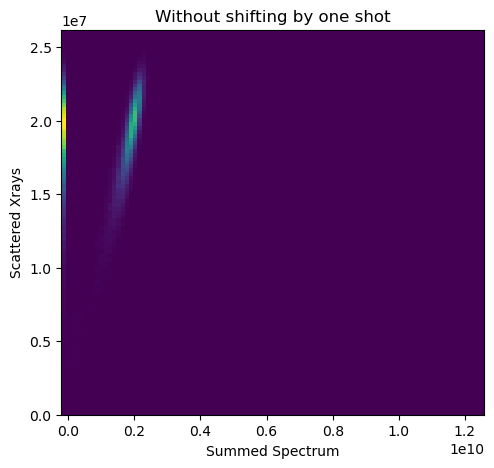

In [7]:
plt.figure(figsize=[12,5])
plt.subplot(1,2,1)
plt.hist2d(spec.sum(axis=1)[xrayOn],scattered_xrays[xrayOn],bins=100)
plt.xlabel('Summed Spectrum')
plt.ylabel('Scattered Xrays')
plt.title('Without shifting by one shot')

Text(0.5, 1.0, 'With shifting by one shot')

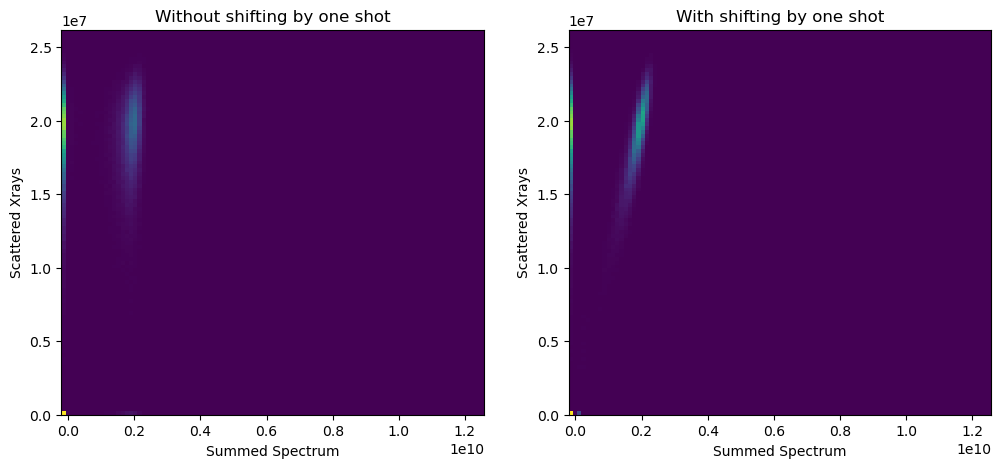

In [6]:
plt.figure(figsize=[12,5])
plt.subplot(1,2,1)
plt.hist2d(spec.sum(axis=1),scattered_xrays,bins=100)
plt.xlabel('Summed Spectrum')
plt.ylabel('Scattered Xrays')
plt.title('Without shifting by one shot')

spec = spec[0:-2];
#azavFiltered = azavFiltered[1:-1];
scattered_xrays = scattered_xrays[1:-1];
xrayOn = xrayOn[1:-1];
plt.subplot(1,2,2)
plt.hist2d(spec.sum(axis=1),scattered_xrays,bins=100)
plt.xlabel('Summed Spectrum')
plt.ylabel('Scattered Xrays')
plt.title('With shifting by one shot')
#xrayOn2 = xrayOn2[1:-1];
#laserOn = laserOn[1:-1];
#dg2traces = dg2traces[1:-1];
#dg2tracesFull = dg2tracesFull[1:-1];
#dg2Sum = dg2Sum[1:-1];